In [ ]:
# import essential
import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")

if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))



In [ ]:
# collect units location information
from general_utils import find_ephys_sessions
from pathlib import Path
from ephys_utils import collect_units_locations_to_csv

# Step 1: discover sessions
_, _, sessions = find_ephys_sessions()
print(f"Total sessions found: {len(sessions)}")


# Step 2: export unit locations
OUT_CSV = Path("/root/capsule/scratch/unit_locations_by_session.csv")

df_unitloc = collect_units_locations_to_csv(
    sessions,
    out_csv=OUT_CSV,
    verbose=True,
)

print("Done.")


In [ ]:
# summary units by region
from general_utils import load_df_with_psth_csv
from behavior_qc_visualization import load_behavior_model_summary_csv
from behavior_qc_metrics_summary import append_model_criteria_result
from behavior_qc_metrics_summary import append_summary_to_df_by_session
from ephys_utils import summarize_units_by_region_and_session
# load the unit_locations
df_unitloc=load_df_with_psth_csv("/root/capsule/scratch/unit_locations_by_session.csv")


# Summary
summary = load_behavior_model_summary_csv("/root/capsule/scratch/behavior_model_summary_ephys_sessions.csv")
summary = append_model_criteria_result(summary)

# append the qc
df_with_summary = append_summary_to_df_by_session(
    df_unitloc,
    summary,
    df_session_col="session_name",
    summary_session_col="session_name",
    summary_cols=[
        "QLearning_L1F1_CK1_softmax_pass_all_criteria",
    ],
    prefix="summary_",
)


summarize_units_by_region_and_session(df_with_summary)

In [3]:
from check_monotonic import load_and_combine_monotonic_unit_dfs
from check_monotonic import summarize_significant_and_monotonic_fractions

combined_df = load_and_combine_monotonic_unit_dfs(
    "/root/capsule/scratch/monotonic_outputs_n_4/ForagingCompareThreshold-value-1/win_m1__0",
    pattern="*.csv",
    recursive=True,
    add_source_file=True,
)
print("combined_df shape (before filtering inside function):", combined_df.shape)

out = summarize_significant_and_monotonic_fractions(
    combined_df,
    alpha=0.05,
    p_col="spearman_p",
    monotonic_col="is_monotonic",
    include_overall=True,
    summary=summary,  # NEW
    # Default criteria_col is 'QLearning_L1F1_CK1_softmax_pass_all_criteria'
    # Override here if you want a different model's criteria:
    # criteria_col="QLearning_L2F1_softmax_pass_all_criteria",
)

combined_df shape (before filtering inside function): (25055, 90)


In [4]:
import pandas as pd
import numpy as np

# Extract the dataframe
df = out['by_brain_region_group']['[SI,MA]']['significant_monotonic_df']

# Make sure spearman_rho is numeric
df = df[df['spearman_rho'].notna()].copy()

# Group by session_name
session_summary = []

for session, sub in df.groupby('session_name'):
    
    # Positive units
    pos = sub[sub['spearman_rho'] > 0]
    neg = sub[sub['spearman_rho'] < 0]
    
    session_summary.append({
        'session_name': session,
        'n_positive': len(pos),
        'n_negative': len(neg),
        'positive_unit_index': pos['unit_index'].tolist(),
        'negative_unit_index': neg['unit_index'].tolist(),
    })

session_summary_df = pd.DataFrame(session_summary)

session_summary_df


,session_name,n_positive,n_negative,positive_unit_index,negative_unit_index
0,ecephys_769884_2025-01-16_18-33-11_sorted_2025...,3,2,"[445, 454, 197]","[288, 191]"
1,ecephys_776293_2025-02-14_15-19-17_sorted_2025...,9,31,"[1877, 1840, 2036, 1836, 1698, 2042, 1671, 189...","[1390, 1644, 1849, 1584, 1396, 1850, 1439, 141..."
2,ecephys_776293_2025-02-18_12-51-36_sorted_2025...,13,7,"[1787, 1956, 1984, 2162, 1813, 2094, 1974, 210...","[1820, 1914, 2124, 1918, 1983, 1836, 1815]"
3,ecephys_776293_2025-02-19_14-01-07_sorted_2025...,1,1,[2400],[2397]
4,ecephys_780618_2025-04-16_15-54-21_sorted_2025...,3,4,"[2193, 1919, 1900]","[1910, 2002, 2168, 2194]"
5,ecephys_781471_2025-03-31_14-33-03_sorted_2025...,0,8,[],"[1850, 1857, 1858, 1855, 1854, 1819, 1827, 1848]"


In [59]:
session_summary_df['session_name'][2]

'ecephys_776293_2025-02-18_12-51-36_sorted_2025-03-30_05-50-33'

In [75]:
# calculate the tdr
import numpy as np
from ephys_dimension_reduction_tdr import tdr_from_psth
from create_psth import load_zarr
from general_utils import smart_read_csv

session_name = session_summary_df['session_name'][4]
row = session_summary_df.loc[
    session_summary_df["session_name"] == session_name
]
positive_unit_index = row["positive_unit_index"].iloc[0]
negative_unit_index = row["negative_unit_index"].iloc[0]

binsize = '0.2'
align = "go_cue"
time_window0=[-1,-0]
latent_var='ForagingCompareThreshold-value-1'


psth_da = load_zarr(f"/root/capsule/scratch/psth_results/{session_name}_{binsize}s.zarr")
df = smart_read_csv(f"/root/capsule/scratch/behavior_summary/behavior_summary-{session_name}.csv")


# keep only units whose unit_index is in positive_unit_index
mask_positive = np.isin(psth_da.coords["unit_index"].values, positive_unit_index)

psth_da_positive = psth_da.isel(unit=mask_positive)

mask_negative = np.isin(psth_da.coords["unit_index"].values, negative_unit_index)

psth_da_negative = psth_da.isel(unit=mask_negative)

keep_ids = np.asarray(df['response_trials'][0], dtype=int)


out_all = tdr_from_psth(
    psth_da,
    latent=df[latent_var][0],
    align=align,
    time_window=time_window,
    include_trials=keep_ids,
    require_all_ids=True,
    save_path=f"/root/capsule/scratch/long_time_scale_correlation/tdr_{session_name}_{latent_var}_timewindow_{time_window0[0]}_{time_window0[1]}_out_all.zarr",
    save_format="zarr",
)



out_positive = tdr_from_psth(
    psth_da_positive,
    latent=df[latent_var][0],
    align=align,
    time_window=time_window,
    include_trials=keep_ids,
    require_all_ids=True,
    save_path=f"/root/capsule/scratch/long_time_scale_correlation/tdr_{session_name}_{latent_var}_timewindow_{time_window0[0]}_{time_window0[1]}_sig_monotonic_positive.zarr",
    save_format="zarr",
)



out_negative = tdr_from_psth(
    psth_da_negative,
    latent=df[latent_var][0],
    align=align,
    time_window=time_window,
    include_trials=keep_ids,
    require_all_ids=True,
    save_path=f"/root/capsule/scratch/long_time_scale_correlation/tdr_{session_name}_{latent_var}_timewindow_{time_window0[0]}_{time_window0[1]}_sig_monotonic_negative.zarr",
    save_format="zarr",
)


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_tdr.py:1165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.82, 1])


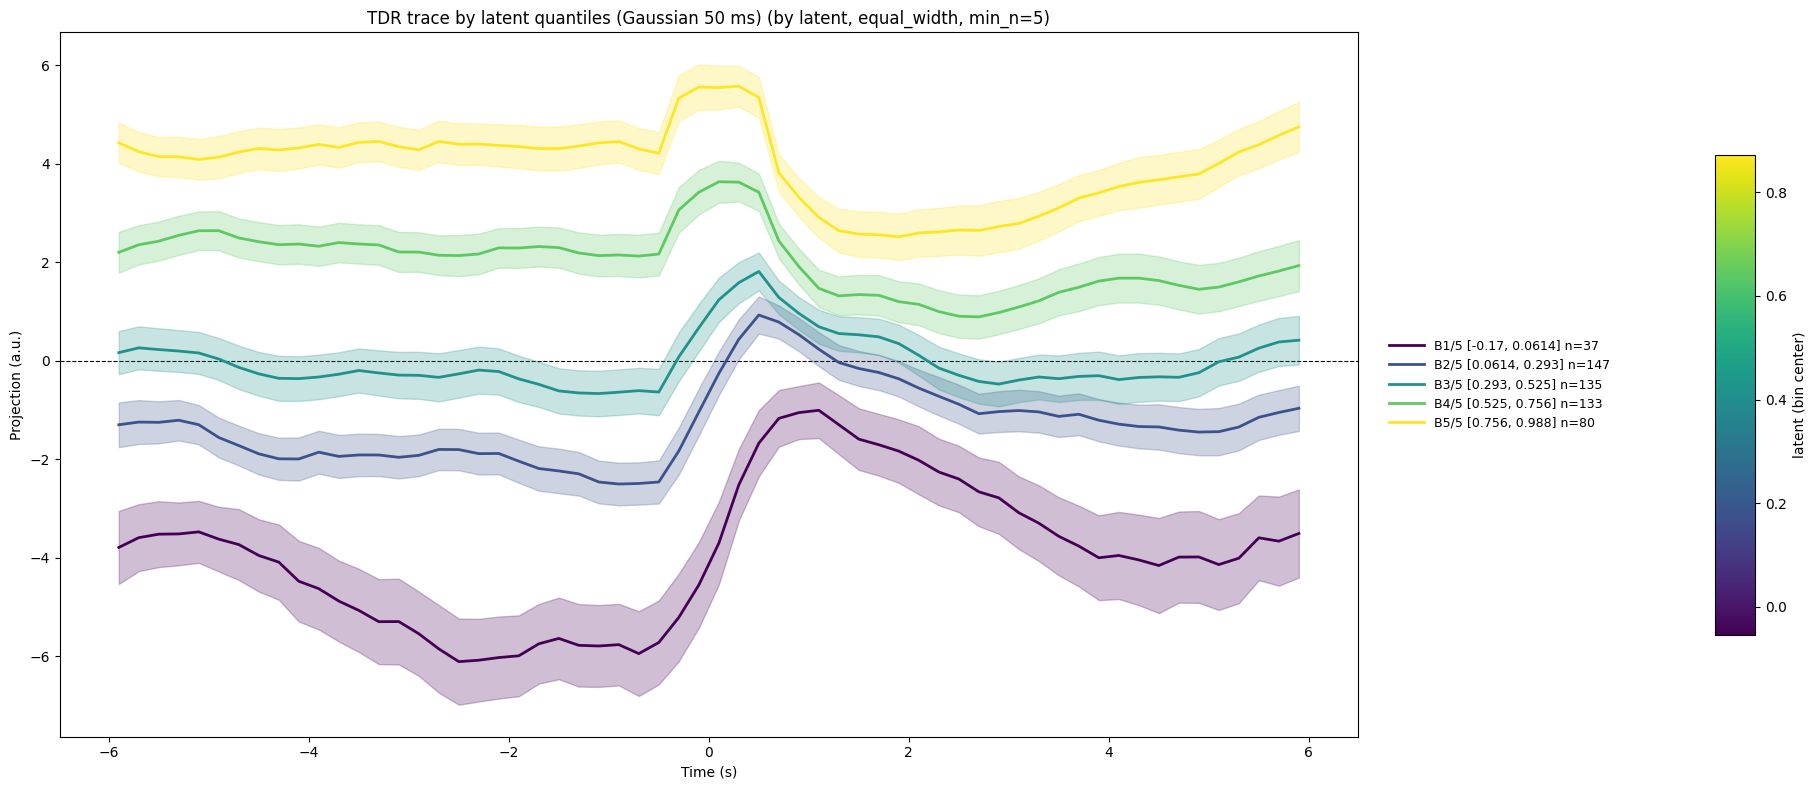

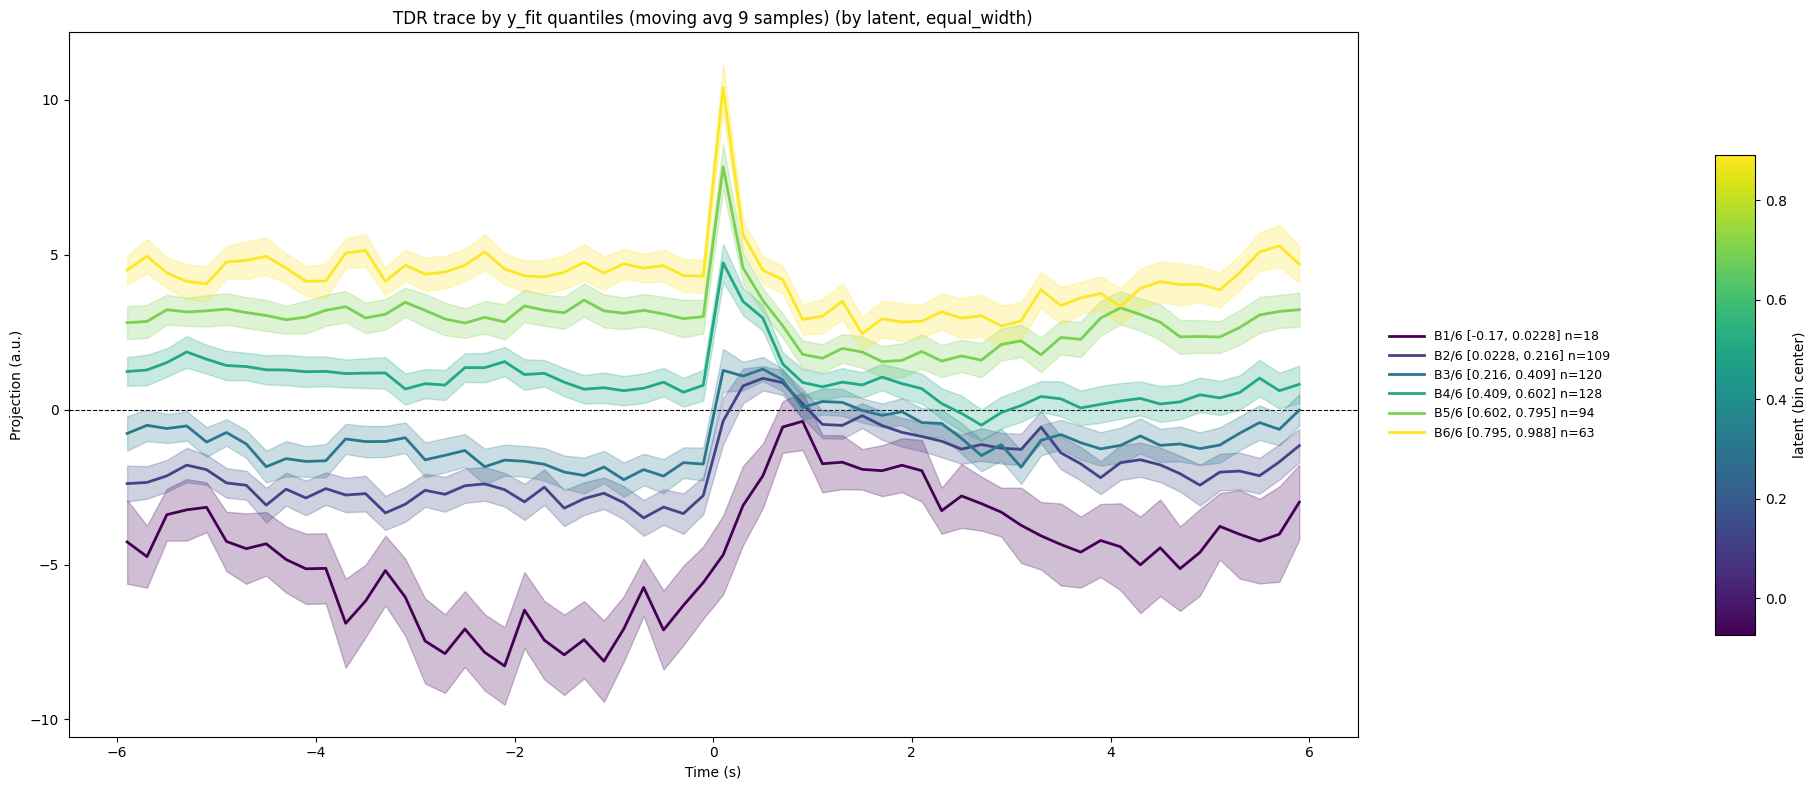

In [74]:
# load and visualize the tdr 

import xarray as xr

from ephys_dimension_reduction_tdr import plot_tdr_trace_by_quantile

session_name = session_summary_df['session_name'][0]

path = f"/root/capsule/scratch/long_time_scale_correlation/tdr_{session_name}_{latent_var}_timewindow_{time_window0[0]}_{time_window0[1]}_out_all.zarr"
#path = f"/root/capsule/scratch/long_time_scale_correlation/tdr_{session_name}_{latent_var}_timewindow_{time_window0[0]}_{time_window0[1]}_sig_monotonic_negative.zarr"
#path = f"/root/capsule/scratch/long_time_scale_correlation/tdr_{session_name}_{latent_var}_timewindow_{time_window0[0]}_{time_window0[1]}_sig_monotonic_positive.zarr"


# Open lazily (doesn't load data into RAM yet)
ds = xr.open_zarr(path, consolidated=False)  

Y = ds["projection_trace"].values          # (T_used, Tt)
y_fit = ds["projection"].values            # (T_used,)
w = ds["axis_w"].values                    # (N_units,)
t = ds["time"].values                      # (Tt,)
trial_ids = ds["trial_id"].values          # (T_used,)
unit_ids  = ds["unit_id"].values
latent_inc=ds["latent"].values
latent_inc_z=ds["latent_z"].values





# 1) Gaussian smoothing with sigma = 50 ms before averaging
plot_tdr_trace_by_quantile(
    Y, t, latent=latent_inc, n_quantiles=5,
    group_by="latent", ci="sem", show_trials=False,
    min_traces_per_bin=5,
    smooth={"method":"moving", "window":5, "unit":"samples"},
    title="TDR trace by latent quantiles (Gaussian 50 ms)"
)


plot_tdr_trace_by_quantile(
    Y, t, latent=latent_inc, n_quantiles=6,
    y_fit=y_fit, group_by="latent", ci="sem",
    smooth={"method":"moving", "window":1, "unit":"samples"},
    title="TDR trace by y_fit quantiles (moving avg 9 samples)"
)


In [56]:
# project the entire session to the tdr dimension
import xarray as xr
from create_psth import extract_neuron_psth_full_session_to_zarr
from ephys_dimension_reduction_tdr import project_full_session_to_tdr
from nwb_utils import NWBUtils

nwb_data,a=NWBUtils.combine_nwb(session_name = "ecephys_776293_2025-02-14_15-19-17_sorted_2025-02-28_21-37-07")
path = f"/root/capsule/scratch/long_time_scale_correlation/tdr_{session_name}_{latent_var}_timewindow_{time_window0[0]}_{time_window0[1]}_out_all.zarr"

# Open lazily (doesn't load data into RAM yet)
tdr_result = xr.open_zarr(path, consolidated=False)  


ds_full = extract_neuron_psth_full_session_to_zarr(
    nwb_data,
    bin_size=0.5,
    time_range=None,        # <-- inferred from ALL units
    t0_mode="min_spike",    # <-- makes time start at 0
)

print("counts_full sum:", int(ds_full["counts_full"].sum()))
print("psth_full min/max:", float(ds_full["psth_full"].min()), float(ds_full["psth_full"].max()))



y_full = project_full_session_to_tdr(ds_full, tdr_result, norm_mode="zscore_time")
y_full



Found ephys NWB: /root/capsule/data/ecephys_776293_2025-02-14_15-19-17_sorted_2025-02-28_21-37-07/nwb/ecephys_776293_2025-02-14_15-19-17_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_776293_2025-02-14_15-19-17_sorted_2025-02-28_21-37-07/nwb/ecephys_776293_2025-02-14_15-19-17_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/776293_2025-02-14_15-19-17.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/776293_2025-02-14_15-19-17.nwb
Successfully appended units table to behavior NWB.
Number of units passing QC: 800
Saved full-session PSTH to /root/capsule/results/776293_2025-02-14_15-19-17.json_full_psth.zarr [t0_mode=min_spike, time_range=(0.0, 5471.165618285537)]
counts_full sum: 30742388
psth_full min/max: 0.0 234.0


<xarray.DataArray 'tdr_projection_full_session' (time: 10943)> Size: 88kB
array([-0.98037463,  0.19282473, -0.53778594, ...,  0.70569872,
        0.00633865, -1.0914432 ], shape=(10943,))
Coordinates:
  * time     (time) float64 88kB 0.25 0.75 1.25 ... 5.47e+03 5.471e+03 5.471e+03
Attributes:
    psth_key:                 psth_full
    norm_mode:                zscore_time
    n_units_in_tdr:           1295
    n_units_in_ds_full:       800
    n_units_used:             411
    fraction_tdr_units_used:  0.3173745173745174

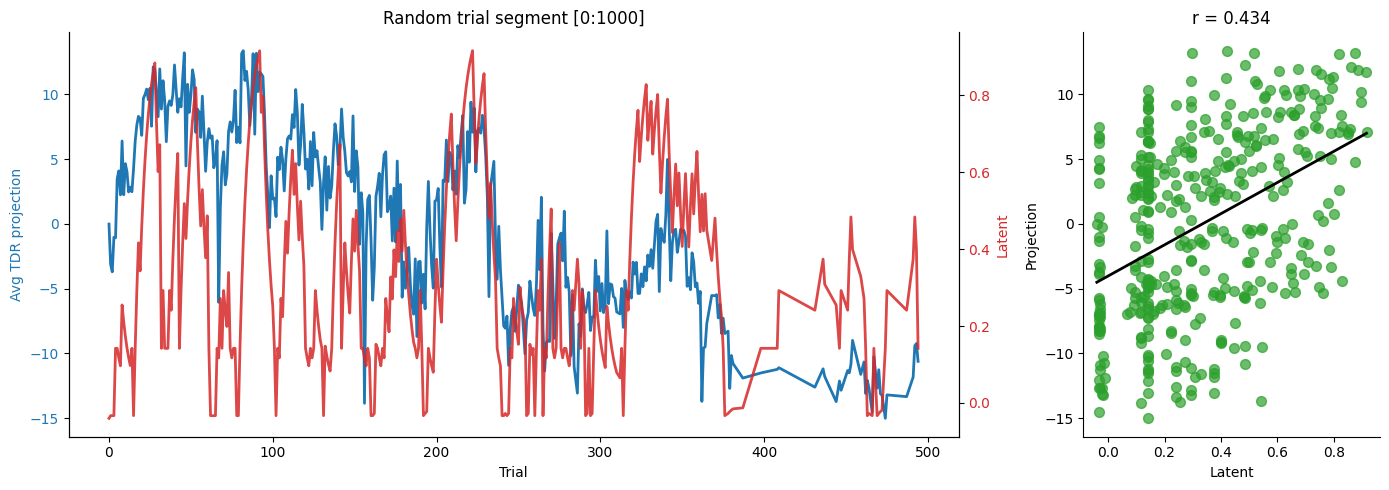

In [80]:
"""
Visualize the relationship between neural projection activity and a latent value
variable over a randomly selected contiguous segment of trials.

This script:
1. Computes a per-trial neural projection value by averaging the TDR projection
   trace within a specified pre-event time window.
2. Randomly selects a contiguous block of trials (window_trials).
3. Plots:
   - Left panel: Trial-by-trial trajectories of neural projection and latent value
     (dual y-axes) across the selected segment.
   - Right panel: Scatter plot of projection vs latent within the same segment,
     with a linear fit and Pearson correlation coefficient.

Purpose:
To visualize trial-level co-fluctuation between neural projection activity
and the model-derived latent variable, and to quantify their local correlation
within a short behavioral epoch.
"""


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import xarray as xr

session_name = session_summary_df['session_name'][4]

path = f"/root/capsule/scratch/long_time_scale_correlation/tdr_{session_name}_{latent_var}_timewindow_{time_window0[0]}_{time_window0[1]}_sig_monotonic_positive.zarr"
path = f"/root/capsule/scratch/long_time_scale_correlation/tdr_{session_name}_{latent_var}_timewindow_{time_window0[0]}_{time_window0[1]}_sig_monotonic_negative.zarr"
path = f"/root/capsule/scratch/long_time_scale_correlation/tdr_{session_name}_{latent_var}_timewindow_{time_window0[0]}_{time_window0[1]}_out_all.zarr"

ds = xr.open_zarr(path, consolidated=False)  


# ---- parameters ----
time_window = (-2,0)
window_trials = 1000   # number of consecutive trials to show

# ---- compute per-trial projection ----
proj_trace = ds["projection_trace"]
y_trial = proj_trace.sel(time=slice(time_window[0], time_window[1])).mean("time")

latent = ds["latent"]
trial_ids = ds["trial_id"].values

y_vals = y_trial.values
lat_vals = latent.values

n_trials = len(trial_ids)

# ---- randomly choose a contiguous window ----
if window_trials >= n_trials:
    start = 0
else:
    start = np.random.randint(0, n_trials - window_trials)

end = start + window_trials

# slice
x_seg = trial_ids[start:end]
y_seg = y_vals[start:end]
lat_seg = lat_vals[start:end]

# correlation on this segment
r, p = pearsonr(y_seg, lat_seg)

# -----------------------------
# layout (wide left, narrow right)
# -----------------------------
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ===== Left: trial-wise curves =====
color_proj = "#1f77b4"
color_lat  = "#d62728"

ax1.plot(x_seg, y_seg, color=color_proj, linewidth=2)
ax1.set_xlabel("Trial")
ax1.set_ylabel("Avg TDR projection", color=color_proj)
ax1.tick_params(axis="y", labelcolor=color_proj)
ax1.set_title(f"Random trial segment [{start}:{end}]")
ax1.spines["top"].set_visible(False)

ax1b = ax1.twinx()
ax1b.plot(x_seg, lat_seg, color=color_lat, linewidth=2, alpha=0.85)
ax1b.set_ylabel("Latent", color=color_lat)
ax1b.tick_params(axis="y", labelcolor=color_lat)
ax1b.spines["top"].set_visible(False)

# ===== Right: scatter =====
ax2.scatter(lat_seg, y_seg, s=50, alpha=0.7, color="#2ca02c")

coef = np.polyfit(lat_seg, y_seg, 1)
xfit = np.linspace(np.min(lat_seg), np.max(lat_seg), 200)
yfit = coef[0] * xfit + coef[1]
ax2.plot(xfit, yfit, color="black", linewidth=2)

ax2.set_xlabel("Latent")
ax2.set_ylabel("Projection")
ax2.set_title(f"r = {r:.3f}")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


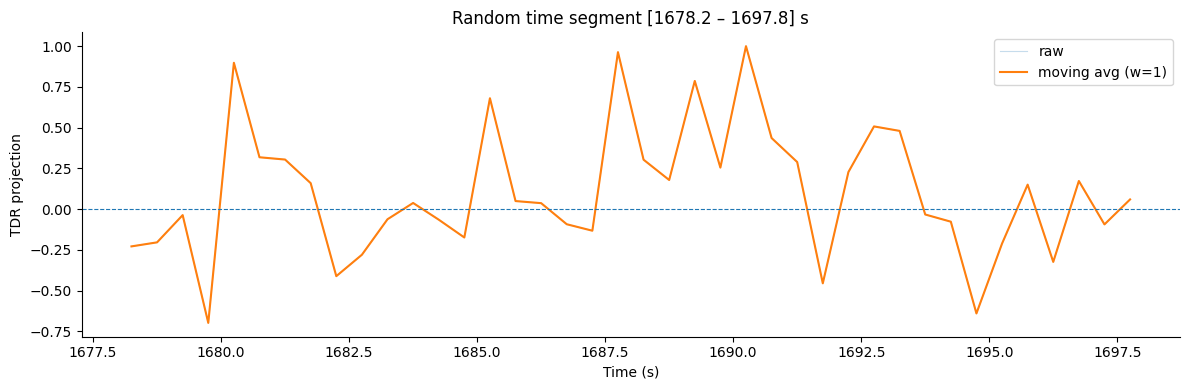

In [81]:
"""
Visualize continuous neural projection dynamics over a randomly selected
time segment.

This script:
1. Applies a moving-average smoothing (window size in bins) to the full
   TDR projection time series.
2. Randomly selects a contiguous time window of fixed duration
   (segment_seconds).
3. Plots:
   - The raw projection trace (light, semi-transparent).
   - The smoothed projection trace (moving average).
   - A zero-reference line.

Purpose:
To inspect slow fluctuations and temporal structure of the neural projection
signal in continuous time, independent of trial boundaries. This helps
evaluate drift, stability, low-frequency structure, and baseline crossings
of the value-axis projection.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---- smoothing window (in bins) ----
window = 1
kernel = np.ones(window) / window
y_smooth = np.convolve(y_full.values, kernel, mode="same")

t = y_full["time"].values
y_raw = y_full.values

# ---- choose random contiguous time segment ----
segment_seconds = 20   # length of window in seconds (e.g., 10 min)
bin_size = float(np.mean(np.diff(t)))  # infer bin size
segment_bins = int(segment_seconds / bin_size)

n_total = len(t)

if segment_bins >= n_total:
    start_idx = 0
else:
    start_idx = np.random.randint(0, n_total - segment_bins)

end_idx = start_idx + segment_bins

t_seg = t[start_idx:end_idx]
y_raw_seg = y_raw[start_idx:end_idx]
y_smooth_seg = y_smooth[start_idx:end_idx]

# ---- plot ----
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(t_seg, y_raw_seg,
        alpha=0.25, linewidth=0.8, label="raw")

ax.plot(t_seg, y_smooth_seg,
        linewidth=1.5, label=f"moving avg (w={window})")

ax.set_xlabel("Time (s)")
ax.set_ylabel("TDR projection")
ax.set_title(f"Random time segment [{t_seg[0]:.1f} – {t_seg[-1]:.1f}] s")

ax.axhline(0, linestyle="--", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend()
plt.tight_layout()
plt.show()
